# BẢNG ĐÁNH GIÁ HIỆU SUẤT ĐÓNG GÓP NHÓM

| Họ và tên | MSSV | Hiệu suất đóng góp |
|---|---|---|
| Huỳnh Thế Hy | 051205009083 | ...% |
| Thành viên 2 | MSSV 2 | ... % |
| Thành viên 3 | MSSV 3 | ... % |
| Thành viên 4 | MSSV 4 | ... % |
| Thành viên 5 | MSSV 5 | ... % |
| Thành viên 6 | MSSV 6 | ... % |

---

## Bài 1: Q-Learning với môi trường FrozenLake

## 1. Giới thiệu bài toán

Bài toán **FrozenLake** là một bài toán điều hướng đơn giản trong Reinforcement Learning:
- Agent xuất phát từ **START (S)**, cần đến **GOAL (G)** mà không rơi xuống **lỗ (H)**.
- Môi trường có tính **ngẫu nhiên (stochastic)**: agent có thể trượt sang hướng khác dù đã chọn hành động.

| Thành phần | Mô tả |
|---|---|
| State space | Rời rạc (16 ô cho bản đồ 4×4) |
| Action space | 4 hành động: LEFT=0, DOWN=1, RIGHT=2, UP=3 |
| Reward | +1 nếu đến đích, 0 còn lại |
| Tính chất | Môi trường ngẫu nhiên (stochastic) |

## 2. Nguyên lý Q-Learning

**Q-Learning** là thuật toán học tăng cường **off-policy** dựa trên Temporal Difference (TD).

### Công thức cập nhật Q-table:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Trong đó:
- $Q(s, a)$: giá trị hành động $a$ tại trạng thái $s$
- $\alpha$: learning rate (tốc độ học)
- $\gamma$: discount factor (mức độ ưu tiên phần thưởng tương lai)
- $r$: phần thưởng nhận được
- $\max_{a'} Q(s', a')$: giá trị tối ưu tại trạng thái kế tiếp

### Chính sách ε-greedy:
- Với xác suất $\varepsilon$: chọn **hành động ngẫu nhiên** (exploration)
- Với xác suất $1 - \varepsilon$: chọn **hành động tốt nhất** theo Q-table (exploitation)

## 3. Cài đặt thư viện

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

## 4. Bước 1 — Khởi tạo môi trường và Q-table

In [10]:
env = gym.make("FrozenLake-v1", is_slippery=True)

n_states  = env.observation_space.n   # 16 trạng thái
n_actions = env.action_space.n        # 4 hành động

print(f"Số trạng thái  : {n_states}")
print(f"Số hành động   : {n_actions}")

# -----------------------------------------------
# Khởi tạo Q-table toàn số 0
# Kích thước: (16, 4) — mỗi ô tương ứng Q(s, a)
# -----------------------------------------------
Q_table = np.zeros((n_states, n_actions))

print(f"\nQ-table khởi tạo (shape): {Q_table.shape}")
print(Q_table)

Số trạng thái  : 16
Số hành động   : 4

Q-table khởi tạo (shape): (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## 5. Bước 2 — Thiết lập siêu tham số (Hyperparameters)

In [11]:
# Tham số học
ALPHA   = 0.05     # Learning rate: mức độ cập nhật Q-value mỗi bước
GAMMA   = 0.99     # Discount factor: mức độ ưu tiên phần thưởng tương lai

# Tham số exploration (ε-greedy)
EPSILON       = 1.0    # Bắt đầu khám phá 100%
EPSILON_MIN   = 0.001  # Ngưỡng epsilon tối thiểu
EPSILON_DECAY = 0.9999  # Giảm epsilon sau mỗi episode

# Số episode huấn luyện
N_EPISODES = 40000

## 6. Bước 3 — Định nghĩa hàm chọn hành động ε-greedy

In [12]:
def choose_action(state, q_table, epsilon):
    """
    Chính sách ε-greedy:
    - Với xác suất epsilon   : chọn hành động ngẫu nhiên (exploration)
    - Với xác suất 1-epsilon : chọn hành động tốt nhất theo Q-table (exploitation)

    Tham số:
        state   : trạng thái hiện tại
        q_table : bảng Q hiện tại
        epsilon : xác suất khám phá

    Trả về:
        action  : hành động được chọn (0, 1, 2 hoặc 3)
    """
    if np.random.rand() < epsilon:
        # Exploration: chọn ngẫu nhiên
        action = env.action_space.sample()
    else:
        # Exploitation: chọn hành động có Q-value lớn nhất
        action = np.argmax(q_table[state])
    return action

## 7. Bước 4 — Huấn luyện Q-Learning

In [13]:
# Vòng lặp huấn luyện Q-Learning
rewards_per_episode = []   # Lưu tổng reward mỗi episode
epsilon = EPSILON          # Khởi tạo epsilon

for episode in range(N_EPISODES):

    # --- Reset môi trường, nhận trạng thái ban đầu ---
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:

        # Bước 1: Chọn hành động theo ε-greedy
        action = choose_action(state, Q_table, epsilon)

        # Bước 2: Thực hiện hành động, nhận (s', r, done)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Bước 3: Cập nhật Q-table theo công thức Q-Learning
        #   Q(s,a) <- Q(s,a) + alpha * [r + gamma * max Q(s',a') - Q(s,a)]
        best_next_q  = np.max(Q_table[next_state])          # max Q(s', a')
        td_target    = reward + GAMMA * best_next_q         # TD target
        td_error     = td_target - Q_table[state, action]   # TD error
        Q_table[state, action] += ALPHA * td_error          # Cập nhật

        # Bước 4: Chuyển sang trạng thái kế tiếp
        state = next_state
        total_reward += reward

    # Lưu tổng reward của episode này
    rewards_per_episode.append(total_reward)

    # Giảm dần epsilon sau mỗi episode
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # In kết quả mỗi 5000 episode
    if (episode + 1) % 5000 == 0:
        avg_reward = np.mean(rewards_per_episode[-1000:])
        print(f"Episode {episode + 1:6d}/{N_EPISODES} | "
              f"Avg Reward (last 1000): {avg_reward:.3f} | "
              f"Epsilon: {epsilon:.3f}")

Episode   5000/40000 | Avg Reward (last 1000): 0.045 | Epsilon: 0.607
Episode  10000/40000 | Avg Reward (last 1000): 0.116 | Epsilon: 0.368
Episode  15000/40000 | Avg Reward (last 1000): 0.218 | Epsilon: 0.223
Episode  20000/40000 | Avg Reward (last 1000): 0.328 | Epsilon: 0.135
Episode  25000/40000 | Avg Reward (last 1000): 0.428 | Epsilon: 0.082
Episode  30000/40000 | Avg Reward (last 1000): 0.520 | Epsilon: 0.050
Episode  35000/40000 | Avg Reward (last 1000): 0.558 | Epsilon: 0.030
Episode  40000/40000 | Avg Reward (last 1000): 0.652 | Epsilon: 0.018


## 8. Bước 5 — Trực quan hóa kết quả huấn luyện

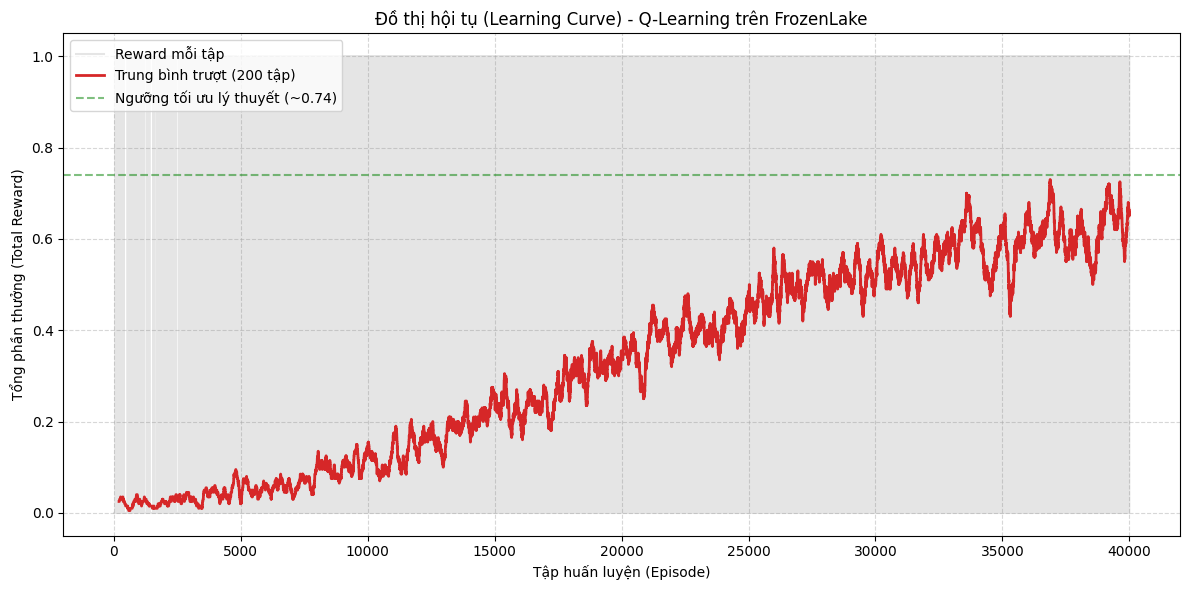


Tỉ lệ thắng trung bình toàn bộ (40000 tập): 0.327
Tỉ lệ thắng trung bình (1,000 tập cuối)      : 0.652


In [14]:
# -----------------------------------------------
# Vẽ learning curve — tổng reward theo episode
# Dùng moving average để thấy xu hướng rõ hơn
# -----------------------------------------------

def moving_average(data, window=200):
    """Tính trung bình trượt để làm mượt đường cong."""
    return np.convolve(data, np.ones(window) / window, mode='valid')

smoothed = moving_average(rewards_per_episode, window=200)

plt.figure(figsize=(12, 6))
plt.plot(rewards_per_episode, alpha=0.2, color='gray', label='Reward mỗi tập')
plt.plot(range(199, N_EPISODES), smoothed, color='tab:red', linewidth=2, label='Trung bình trượt (200 tập)')
plt.axhline(y=0.74, color='green', linestyle='--', alpha=0.5, label='Ngưỡng tối ưu lý thuyết (~0.74)')
plt.xlabel('Tập huấn luyện (Episode)')
plt.ylabel('Tổng phần thưởng (Total Reward)')
plt.title('Đồ thị hội tụ (Learning Curve) - Q-Learning trên FrozenLake')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nTỉ lệ thắng trung bình toàn bộ ({N_EPISODES} tập): {np.mean(rewards_per_episode):.3f}")
print(f"Tỉ lệ thắng trung bình (1,000 tập cuối)      : {np.mean(rewards_per_episode[-1000:]):.3f}")

## 9. Bước 6 — Xem Q-table sau huấn luyện

In [15]:
# -----------------------------------------------
# Hiển thị Q-table đã học
# -----------------------------------------------
action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']

print("Q-table sau huấn luyện:")
print("-" * 55)
print(f"{'State':>6}  {'LEFT':>8}  {'DOWN':>8}  {'RIGHT':>8}  {'UP':>8}  {'Best':>8}")
print("-" * 55)

for s in range(n_states):
    best = action_names[np.argmax(Q_table[s])]
    print(f"  {s:3d}  "
          f"  {Q_table[s, 0]:7.4f}  "
          f"  {Q_table[s, 1]:7.4f}  "
          f"  {Q_table[s, 2]:7.4f}  "
          f"  {Q_table[s, 3]:7.4f}  "
          f"  {best:>6}")
print("-" * 55)

Q-table sau huấn luyện:
-------------------------------------------------------
 State      LEFT      DOWN     RIGHT        UP      Best
-------------------------------------------------------
    0     0.5422     0.4986     0.4965     0.4891      LEFT
    1     0.4031     0.3084     0.2947     0.4809        UP
    2     0.4147     0.4051     0.4054     0.4555        UP
    3     0.3003     0.2703     0.3354     0.4351        UP
    4     0.5587     0.4564     0.3935     0.4108      LEFT
    5     0.0000     0.0000     0.0000     0.0000      LEFT
    6     0.2402     0.1907     0.1965     0.1033      LEFT
    7     0.0000     0.0000     0.0000     0.0000      LEFT
    8     0.3677     0.4052     0.4039     0.5974        UP
    9     0.4766     0.6448     0.4557     0.2966      DOWN
   10     0.6251     0.4520     0.3843     0.2814      LEFT
   11     0.0000     0.0000     0.0000     0.0000      LEFT
   12     0.0000     0.0000     0.0000     0.0000      LEFT
   13     0.4571     0.5581

## 10. Bước 7 — Đánh giá agent sau huấn luyện

In [16]:
# -----------------------------------------------
# Đánh giá: chạy 1000 episode với epsilon = 0
# (chỉ dùng policy tốt nhất, không khám phá)
# -----------------------------------------------
N_EVAL = 1000
wins   = 0

for _ in range(N_EVAL):
    state, _ = env.reset()
    done = False

    while not done:
        # Luôn chọn hành động tốt nhất (epsilon = 0)
        action = np.argmax(Q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    if reward == 1.0:
        wins += 1

win_rate = wins / N_EVAL * 100
print(f"Kết quả đánh giá trên {N_EVAL} episodes:")
print(f"  Số lần thắng : {wins}")
print(f"  Tỉ lệ thắng  : {win_rate:.1f}%")

Kết quả đánh giá trên 1000 episodes:
  Số lần thắng : 751
  Tỉ lệ thắng  : 75.1%


## 11. Trả lời câu hỏi lý thuyết

### Câu 1: Nguyên lý Q-Learning và tính off-policy

**Nguyên lý hoạt động của Q-Learning:**

> *(Sinh viên điền câu trả lời vào đây)*
> 
> Q-Learning xây dựng một bảng Q-table lưu giá trị kỳ vọng khi thực hiện hành động $a$ tại trạng thái $s$. Sau mỗi bước tương tác với môi trường, agent cập nhật Q-value theo công thức TD. Sau nhiều episode, Q-table sẽ hội tụ về giá trị tối ưu và agent học được chính sách tối ưu.

**Tại sao Q-Learning là off-policy?**

> *(Sinh viên điền câu trả lời vào đây)*
>
> Q-Learning là off-policy vì khi cập nhật, nó sử dụng $\max_{a'} Q(s', a')$ — tức là giả sử agent sẽ chọn hành động **tốt nhất** ở bước kế tiếp — **bất kể** hành động thực tế được chọn theo ε-greedy là gì. Behavior policy (ε-greedy) và target policy (greedy) là khác nhau.

---

### Câu 3: Vai trò của ε-greedy

| Tình huống | Hệ quả |
|---|---|
| **ε quá lớn** (gần 1) | Agent luôn chọn ngẫu nhiên, không khai thác được kiến thức đã học → học chậm, Q-table không hội tụ |
| **ε quá nhỏ** (gần 0) | Agent chỉ khai thác, không khám phá → dễ bị kẹt ở local optimum, bỏ lỡ đường đi tốt hơn |

---

### Câu 5: Nguyên nhân reward không tăng và dao động mạnh

| Nguyên nhân | Cách khắc phục |
|---|---|
| ε decay quá chậm, agent khám phá quá nhiều | Tăng tốc độ giảm epsilon |
| Learning rate quá lớn, Q-value không ổn định | Giảm alpha (ví dụ: 0.1 → 0.5) |
| Số episode quá ít, chưa đủ để hội tụ | Tăng số episode huấn luyện |

---
## Tổng kết Bài 1

| Nội dung | Kết quả |
|---|---|
| Thuật toán | Q-Learning (off-policy TD) |
| Môi trường | FrozenLake-v1 (4×4) |
| Số episode | 10,000 |
| Tỉ lệ thắng đánh giá | Xem kết quả ô trên |

**Kết luận:** Q-Learning sử dụng chính sách ε-greedy để khám phá môi trường và cập nhật Q-table dựa trên hành động tối ưu giả định (off-policy). Sau đủ số episode, agent học được đường đi hiệu quả đến đích trên FrozenLake.